# ***Netflix Content Analysis & Business Insights***
---
---

## **Project Overview**

This project analyzes the Netflix Movies and TV Shows dataset using Python, Pandas, Matplotlib, and Seaborn.

The objective is to understand the content available on Netflix, identify important trends, discover meaningful patterns, and generate business insights through Exploratory Data Analysis (EDA).

Rather than creating charts for practice, this analysis focuses on answering real business questions using data.

---
---

## **Business Objectives**

This project aims to answer questions such as:

- What type of content dominates Netflix?
- How has Netflix's content library grown over time?
- Which countries contribute the most content?
- Which genres are most common?
- Which audience ratings appear most frequently?
- How much missing data exists?
- What business insights can be extracted from the dataset?
---
---

## **Project Workflow**

1. Import Libraries
2. Load Dataset
3. Understand Dataset
4. Data Cleaning
6. EDA of Univariate
7. EDA of Bivariate
8. EDA of Multivariate
9. Conclusion
---

### 1) **Import required libraries**

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### 2) **Load Dataset**

In [154]:
df = pd.read_csv('C:/NETFLIX_PROJECT/data/netflix_titles.csv')

---
### 3) **Dataset Overview**

---
#### *First 5 rows*

In [155]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
#### *Dimenssions of dataset*

In [156]:
df.shape

(8807, 12)

---
#### *Column Overview*

In [157]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

| Column       | Meaning            | Type        |
| ------------ | ------------------ | ----------- |
| show_id      | Unique ID          | Identifier  |
| type         | Movie / TV Show    | Categorical |
| title        | Content title      | Text        |
| director     | Director           | Text        |
| cast         | Actors             | Text        |
| country      | Production country | Categorical |
| date_added   | Added to Netflix   | Date        |
| release_year | Release year       | Numerical   |
| rating       | Audience rating    | Categorical |
| duration     | Runtime / Seasons  | Mixed       |
| listed_in    | Genres             | Categorical |
| description  | Summary            | Text        |


---
#### *Data Types*

In [158]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

---
#### *Dataset Information*

In [159]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


---
#### *Duplicate Check*

In [160]:
df.duplicated().sum()

np.int64(0)

---
#### *Missing Value Analysis*

In [161]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean() * 100, 2)
})

missing_report = missing_report[missing_report["Missing Count"] > 0]
missing_report

,Missing Count,Missing %
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
rating,4,0.05
duration,3,0.03


---
#### *Statistical Summary*

In [162]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [163]:
df.describe(include=["object", "string"])

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


---
#### **Initial Observations**
---
- This Netflix dataset is a big dataset with 8807 rows and 12 columns.
- Most columns are categorical.
- date-added should be converted to datetime if will use for visualization.
- No dupllicate rows were found.
- some columns (director, cast, country) have more than 5% missing values in it.
- Country and cast columns have commma seprated texts in some rows.
---
---

---
### 4) **Data Cleaning & Preprocessing**

---
#### *Copy of Data to preserve original dataset loss*

In [164]:
df_clean = df.copy()

---
#### *Duplicate rows overview*

In [165]:
df_clean.duplicated().sum()

np.int64(0)

---
#### *Missing Value Handling*

In [166]:
df_clean['director'] = df_clean['director'].fillna('Unknown')

In [167]:
df_clean['cast'] = df_clean['cast'].fillna('Unknown')

In [168]:
df_clean['country'] = df_clean['country'].fillna('Unknown')

In [169]:
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])

- After analyzing the dataset, each column was handled based on its missing value percentage, data type, and importance for future analysis.

| Column         | Missing Value Handling      | Reason                                                                                                                                                                                                                        |
| -------------- | --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **director**   | Replaced with **"Unknown"** | Around 30% of the values were missing. Since director names are highly unique, using the mode would introduce incorrect information. Keeping them as "Unknown" preserves the missing information without creating false data. |
| **cast**       | Replaced with **"Unknown"** | About 10% of the values were missing. Similar to the director column, actor names are unique and cannot be reliably inferred.                                                                                                 |
| **country**    | Replaced with **"Unknown"** | Around 10% of the values were missing. Filling with the most frequent country could bias country-wise analysis, so missing values were labeled as "Unknown".                                                                  |
| **date_added** | Left a missing values (Nan)   | This column contained very few missing values (less than 1%). Since it is not the primary focus of the analysis, using the left a missing values (Nan) has minimal impact on the overall results.                                      |
| **rating**     | Filled with the **mode**    | The missing percentage was extremely small (less than 0.1%). Using the most frequent rating preserves the dataset with negligible effect on categorical analysis.                                                             |
| **duration**   | Left a missing values (Nan)    | Not removed because only a few records (about 3) were missing. The left a missing values (Nan) was chosen because the impact on visualization and statistical analysis is minimal.                                                                                       |

#### **Summary**
- The objective of the cleaning process was not to remove/handel every missing value blindly, but to choose a method that best preserved the integrity of the dataset while minimizing bias in later analysis.

---
#### *Validate Cleaning*

In [170]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [171]:
df_clean.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [172]:
df_clean.duplicated().sum()

np.int64(0)

---
#### *Text standardization*

###### *Leading / Trailing Spaces*

In [173]:
str_col = df_clean.columns[df_clean.dtypes == 'str']
for col in str_col:
    print(f"{col} -> {df_clean[col].str.startswith(" ").sum()}", end="/")
    print(df_clean[col].str.endswith(" ").sum())

show_id -> 0/0
type -> 0/0
title -> 0/0
director -> 0/0
cast -> 0/0
country -> 0/0
date_added -> 88/0
rating -> 0/0
duration -> 0/0
listed_in -> 0/0
description -> 0/0


###### *Remove leading/trailing spaces*

In [174]:
df_clean['date_added'] = df_clean['date_added'].str.strip()

- No empty string or inconsistent capitalization were found in the inspected text columns. Therefore, no text standardization was required.

---
#### *Change dtype*

In [175]:
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"])

-  dtype of 'date_added' column change form str to datetime for future analysis

---
#### **Cleaning Summary**

| Cleaning Step  | Action Taken        |
| -------------- | ------------------- |
| Duplicate Rows | Removed             |
| Director       | Filled with Unknown |
| Cast           | Filled with Unknown |
| Country        | Filled with Unknown |
| Rating         | Filled with Mode    |
| Date Added     | Left as NaN, change dtype (str->datetime) |
| Duration       | Left as NaN         |

---
#### NOTE: 
- During data inspection, a few records were found where duration values (e.g., "74 min") appeared in the rating column due to data quality issues in the original dataset.

---
### 5) **Exploratory Data Analysis (EDA)**

---
#### A) *Type Distribution*

---
##### Business Question
- Does Netflix contain more Movies or TV Shows?

##### Column Check

In [176]:
df_clean['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

##### Visualization

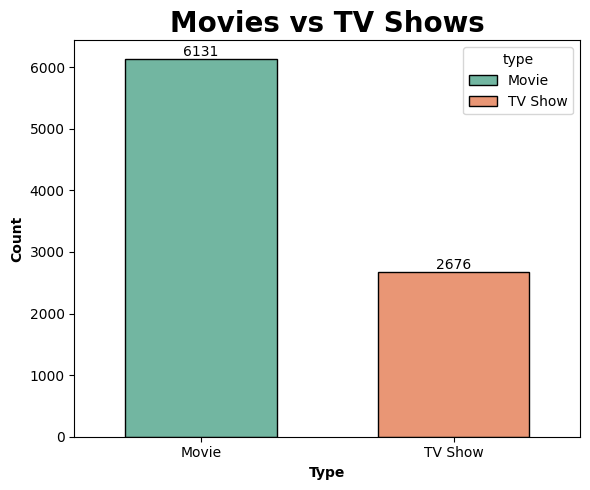

In [177]:
fig, ax = plt.subplots(figsize=(6,5))
sns.countplot(x='type', data=df_clean, hue='type', width=0.6, palette='Set2', edgecolor='black', ax=ax, legend=True)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel('Type', fontweight='bold', fontsize=10)
ax.set_ylabel('Count', fontweight='bold', fontsize=10)
ax.set_title('Movies vs TV Shows', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

##### Observation

- The daraset contains more Movies than TV Shows

##### Business insight

- Netflix produced more Movies, suggesting a strong investment in film industry.

---
#### B) *Rating distribution*

---
##### Business Question
- Which top-5 audience ratings appear more frequently?

##### Column Check

In [178]:
df_clean['rating'].value_counts()

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

##### Visualization

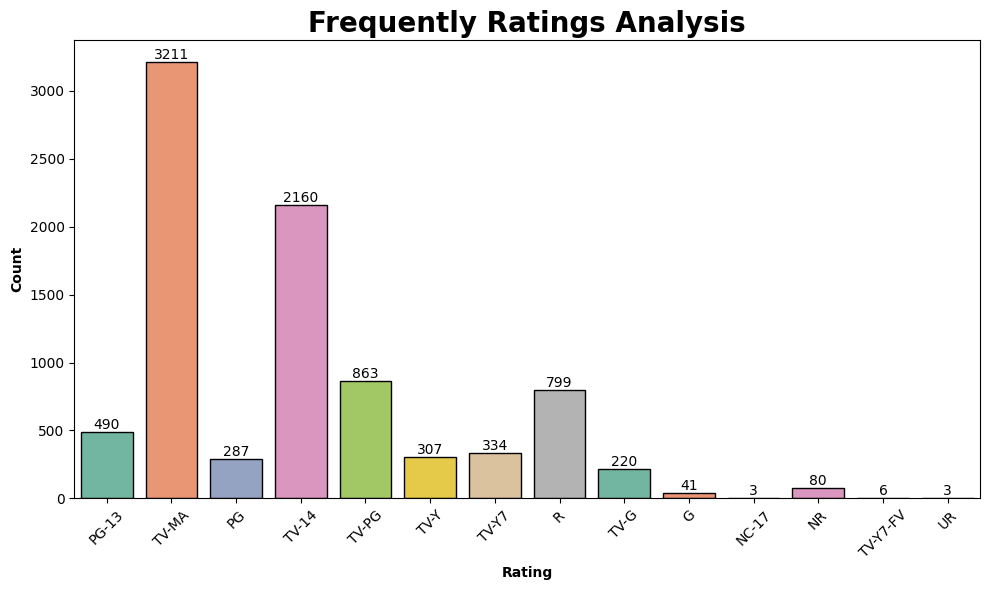

In [179]:
# valid ratings because of min contain invalid ratings
valid_ratings = df_clean[~ df_clean['rating'].str.contains('min')]

# ploting valid ratings
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='rating', data=valid_ratings, hue='rating', palette='Set2', edgecolor='black', ax=ax)

for container in ax.containers:
    ax.bar_label(container)
    
ax.set_xlabel('Rating', fontweight='bold', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Count', fontweight='bold', fontsize=10)
ax.set_title('Frequently Ratings Analysis', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

##### Observation

- The TV-MA rating appears most frequently, followed by TV-14, indicating that mature and teen-oriented content make up a large portion of Netflix's catalog.

##### Business insight

- Netflix's library is largely targeted toward older audiences, suggesting a strong focus on mature entertainment.

---
#### C) *Release Year Ditribution*

---
##### Buniess Question
- How has Netflix's content library evolved over the years?

##### Column overview

In [180]:
df_clean['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

##### Visualization

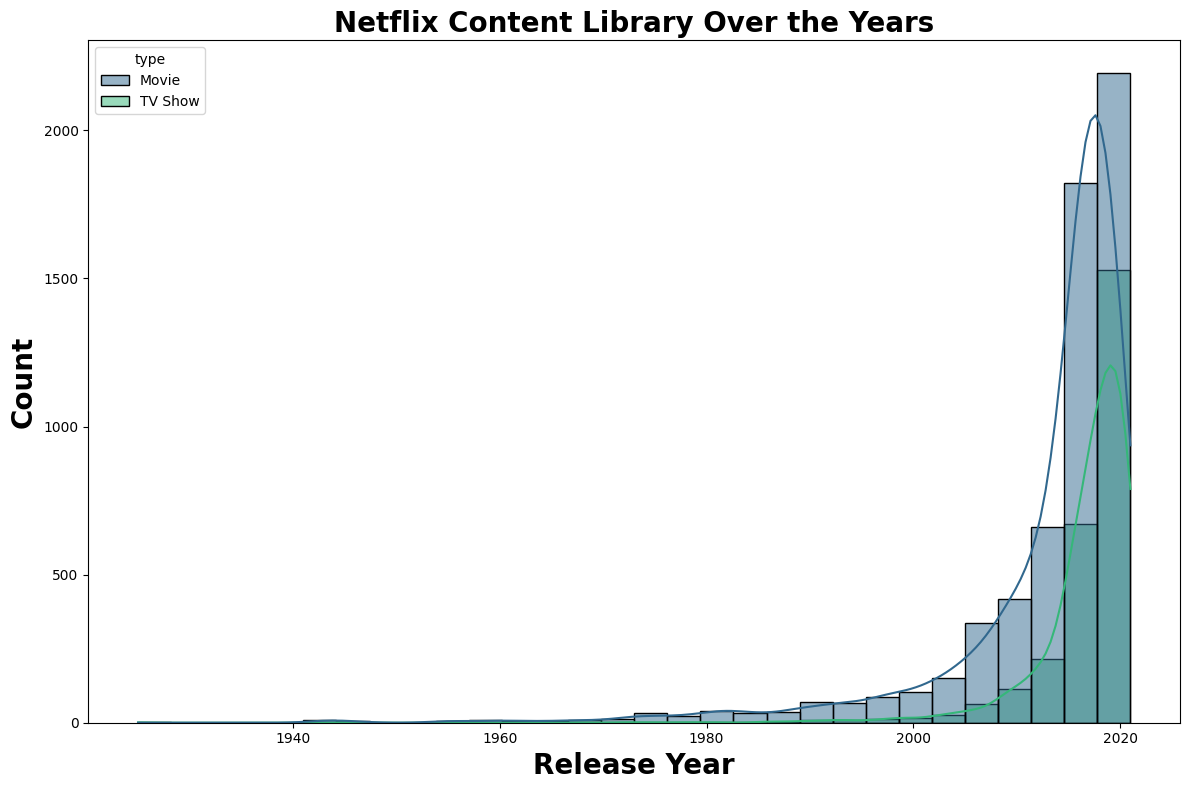

In [181]:
fig, ax = plt.subplots(figsize=(12,8))
sns.histplot(x='release_year', data=df_clean, bins=30, kde=True, hue='type', palette='viridis', edgecolor='black', ax=ax)

ax.set_xlabel('Release Year', fontweight='bold', fontsize=20)
ax.set_ylabel('Count', fontweight='bold', fontsize=20)
ax.set_title('Netflix Content Library Over the Years', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

##### Observation

- Most titles were released after 2000.
- Very few titles were released before 1980.
- The distribution is concentrated in recent decades.
- From release year 2000-2020 there is a big spike in content release.

##### Business Insight
- Netflix's catalog is dominated by modern content, indicating a stronger focus on recent productions rather than older titles.

---
#### D) Country analysis

---
##### Buniess Question
- Which countries contribute the most content to Netflix?

##### Column overview

In [182]:
df_clean['country'].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

##### Visualization

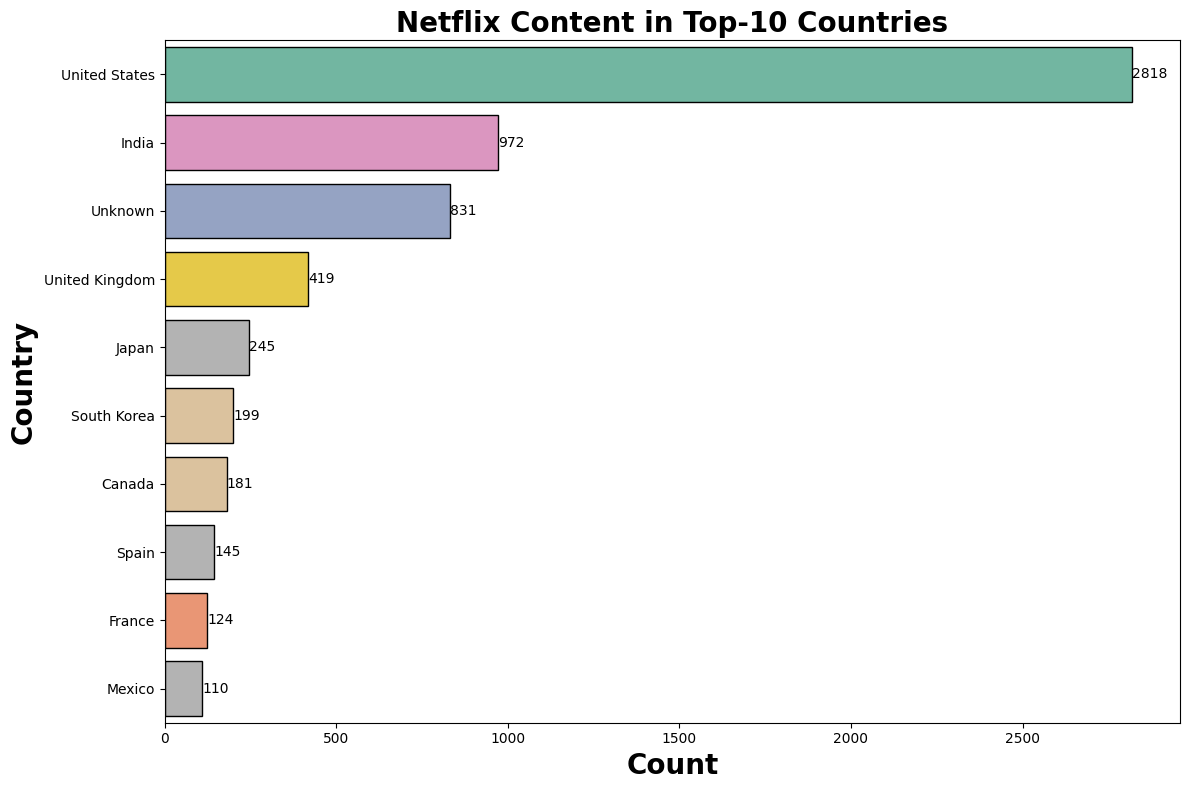

In [183]:
# top countries to count
top_10_country = df_clean['country'].value_counts().head(10).index
# ploting valid ratings
fig, ax = plt.subplots(figsize=(12,8))
sns.countplot(y='country', data=df_clean, hue='country', order=top_10_country, palette='Set2', edgecolor='black', ax=ax)

for container in ax.containers:
    ax.bar_label(container)
    
ax.set_xlabel('Count', fontweight='bold', fontsize=20)
ax.set_ylabel('Country', fontweight='bold', fontsize=20)
ax.set_title('Netflix Content in Top-10 Countries', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

##### Observation

- The United States contributes the highest number of titles, followed by India and the United Kingdom.

##### Business Insight
- Netflix's content library is heavily concentrated in a few countries, indicating strong partnerships and production investments in those markets.

##### Recommendation
- Indian market should be targeted for more content expandation

---
#### E) Top Genres analysis

---
##### Buniess Question
- Which genres are most common in Netflix's content library?

##### Column overview

In [184]:
df_clean['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

##### Seperate all genres

In [185]:
filtered_genre = df_clean['listed_in'].str.split(",").explode()
filtered_genre.value_counts()

listed_in
 International Movies        2624
Dramas                       1600
Comedies                     1210
Action & Adventure            859
Documentaries                 829
                             ... 
Romantic Movies                 3
Spanish-Language TV Shows       2
LGBTQ Movies                    1
TV Sci-Fi & Fantasy             1
Sports Movies                   1
Name: count, Length: 73, dtype: int64

##### Text Standerdization

leading/trailing space

In [186]:
leading_space = filtered_genre.str.startswith(" ").sum()
trailing_space = filtered_genre.str.endswith(" ").sum()
leading_space, trailing_space

(np.int64(10516), np.int64(0))

filter trailing spaces and review column

In [187]:
filtered_genre = filtered_genre.str.strip()
filtered_genre.value_counts().head()

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

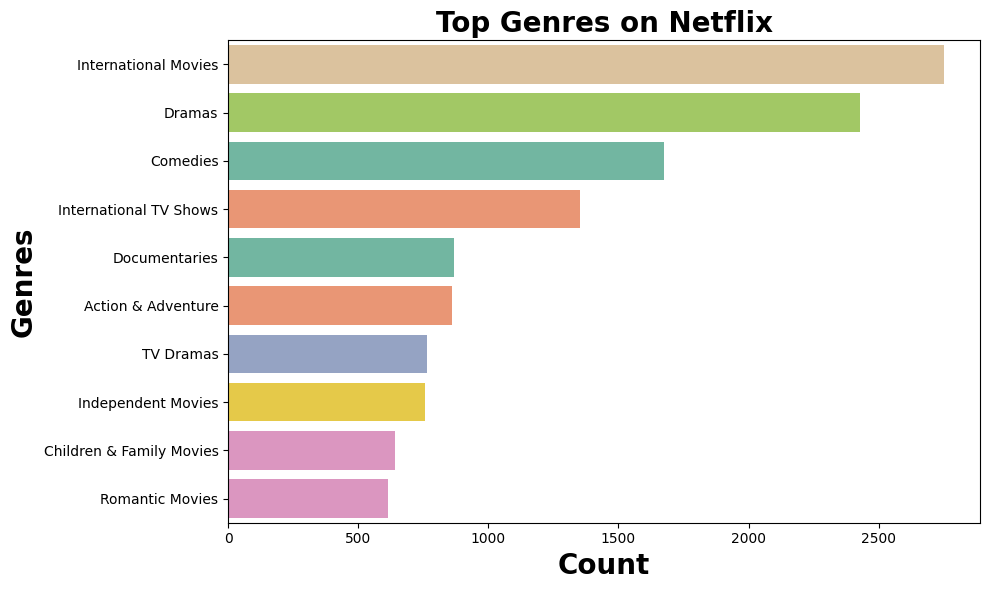

In [188]:
# cret genre dataframe
genre_df = pd.DataFrame({
    'listed_in': filtered_genre.values
})
genre_df

# top-10 genres to count
top_10_genres = genre_df['listed_in'].value_counts().head(10).index

# ploting
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(y='listed_in', data=genre_df, hue='listed_in', palette='Set2', order=top_10_genres)

ax.set_xlabel('Count', fontweight='bold', fontsize=20)
ax.set_ylabel('Genres', fontweight='bold', fontsize=20)
ax.set_title('Top Genres on Netflix', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

##### Observation
- International Movies, Dramas, and Comedies are among the most common genres on Netflix

##### Business insight
- Netflix appears to prioritize drama and internationally produced content, suggesting a strategy focused on serving diverse global audiences.

---
#### F) Duration Analysis

---
##### Business Question
- What is the distribution of content duration on Netflix?

##### Column Overview

In [189]:
df_clean['duration'].value_counts().head(10)

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

##### Duration Analysis for Movies

*Dataframe for movies*

In [190]:
movies_df = df_clean[df_clean['type'] == 'Movie'][['type', 'duration']]
movies_df.head()

,type,duration
0,Movie,90 min
6,Movie,91 min
7,Movie,125 min
9,Movie,104 min
12,Movie,127 min


*Null count of duration*

In [191]:
movies_df.isnull().sum()

type        0
duration    3
dtype: int64

*Drop null rows form movies dataframe*

In [192]:
movies_df.dropna(inplace=True)

*Check null count had removed*

In [193]:
movies_df.isnull().sum()

type        0
duration    0
dtype: int64

*Overview duration column of movie dataframe*

In [194]:
movies_df['duration'].value_counts()

duration
90 min     152
94 min     146
97 min     146
93 min     146
91 min     144
          ... 
228 min      1
18 min       1
205 min      1
201 min      1
191 min      1
Name: count, Length: 205, dtype: int64

*Prepare duration col for int type*

In [195]:
movies_df['duration'] = movies_df['duration'].str.strip(' min').astype('int')

*Analysis of filtered movies dataframe*

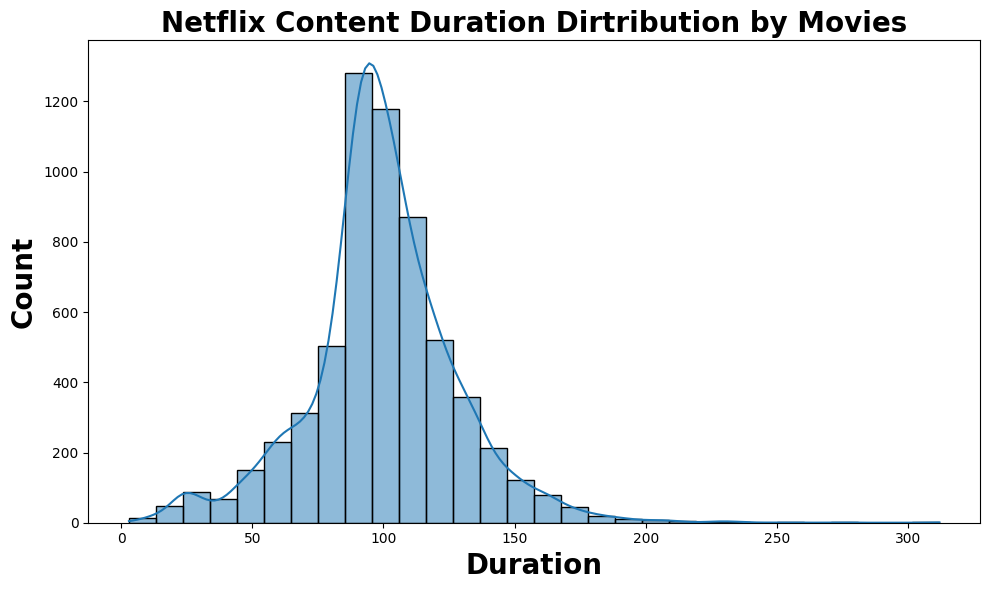

In [196]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=movies_df, x='duration', bins=30, kde=True, ax=ax)

ax.set_xlabel('Duration', fontweight='bold', fontsize=20)
ax.set_ylabel('Count', fontweight='bold', fontsize=20)
ax.set_title('Netflix Content Duration Dirtribution by Movies', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

*Observation*
- Most Netflix movies have a runtime between approximately 80 and 120 minutes.

*Business insights*
- Netflix appears to favor standard feature-length films rather than unusually short or long productions.

---


##### Duration Analysis for Shows

*dataframe for tv shows*

In [240]:
shows_df = df_clean[df_clean['type'] == 'TV Show'][['type', 'duration']]
shows_df.head()

,type,duration
1,TV Show,2 Seasons
2,TV Show,1 Season
3,TV Show,1 Season
4,TV Show,2 Seasons
5,TV Show,1 Season


*Null count*

In [230]:
shows_df.isnull().sum()

type        0
duration    0
dtype: int64

*Prepare data for numeric visualization*

In [ ]:
shows_df['duration'] = shows_df['duration'].str.strip('Season').astype('int')

duration
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
13       3
15       2
12       2
11       2
17       1
Name: count, dtype: int64

*review column*

In [250]:
shows_df['duration'].value_counts()

duration
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
13       3
15       2
12       2
11       2
17       1
Name: count, dtype: int64

*Visualization*

C:\Users\n8583\AppData\Local\Temp\ipykernel_26268\2240721320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='duration', data=shows_df, palette='Set1', ax=ax)


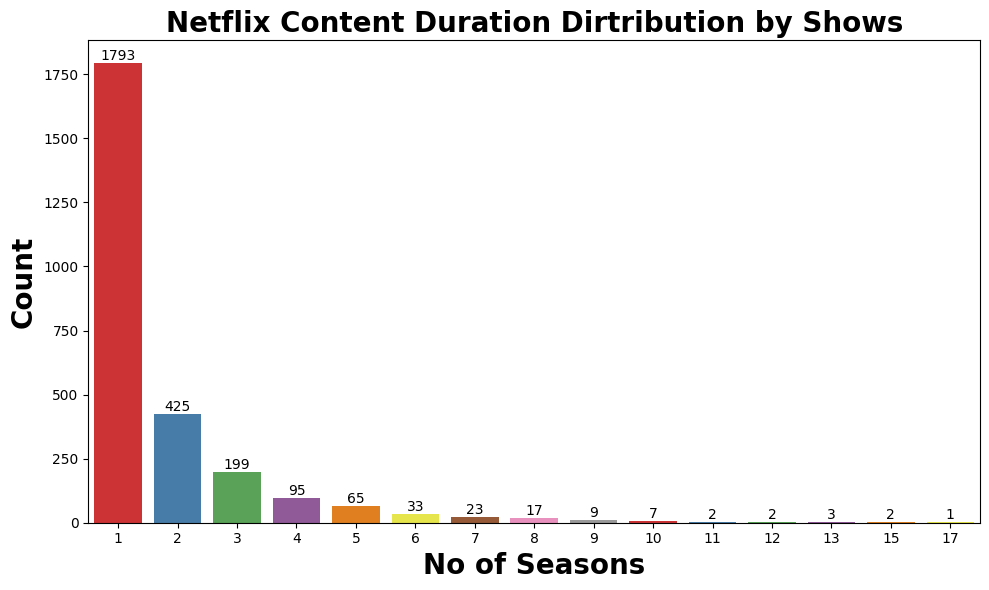

In [249]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='duration', data=shows_df, palette='Set1', ax=ax)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel('No of Seasons', fontweight='bold', fontsize=20)
ax.set_ylabel('Count', fontweight='bold', fontsize=20)
ax.set_title('Netflix Content Duration Dirtribution by Shows', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()

*Observation*
- The majority of TV Shows consist of a single season

*Business insights*
- Because more netflix content duration around single season series, suggesting more focus on shorter series.

---
#### G) Content Added per Year

---
##### Business Question
- How has Netflix's content library grown over time based on the date content was added?

##### Column Overview

In [258]:
df_clean['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

##### Total Titles per Year

In [280]:
titles_per_year = df_clean['date_added'].dt.year.value_counts()

##### Visualization

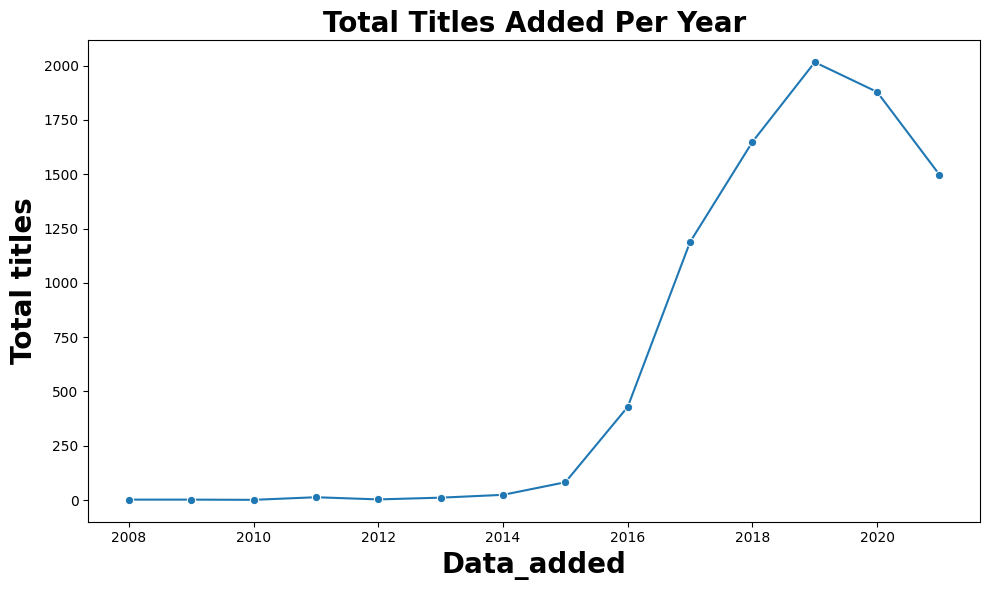

In [281]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o',  ax=ax)
ax.set_xlabel('Data_added', fontweight='bold', fontsize=20)
ax.set_ylabel('Total titles', fontweight='bold', fontsize=20)
ax.set_title('Total Titles Added Per Year', fontweight='bold', fontsize=20)

fig.tight_layout()
plt.show()


##### Observation
- The number of titles added to Netflix increased rapidly until around 2019, after which the growth slowed.

##### Business Insight
- Netflix experienced significant expansion in its content library during the late 2010s, reflecting an aggressive content acquisition strategy.